# Hotness Score — NN Win Probability

Same structure as notebook 01, but win probability is computed by the trained NN model instead of the formula.

Matches:
- **HOT**: DC vs GT (IPL 2026, Apr 8), IND vs PAK (T20 WC 2024, Jun 9)
- **COLD**: RR vs MI (IPL 2026, Apr 7), MI vs RR (IPL 2025, May 1)
- **NEW**: KKR vs LSG (IPL 2026, Apr 9) — LSG won by 3 wkts last ball
- **NEW**: RCB vs RR (IPL 2026, Apr 10) — RR won by 6 wkts chasing 202

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
from pathlib import Path

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA       = '../data/raw/'
MODELS_DIR = Path('../models')
FIG_DIR    = Path('../data/figures/06_hotness_nn')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load NN model

In [2]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ckpt = torch.load(MODELS_DIR / 'win_prob_nn.pt', weights_only=False)
model = WinProbNet(input_dim=ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

FEATURE_COLS = ckpt['feature_cols']
X_mean       = ckpt['X_mean']
X_std        = ckpt['X_std']

print('Model loaded:', FEATURE_COLS)


def nn_win_prob(runs_needed_arr, balls_remaining_arr, wickets_fallen_arr):
    """Vectorised NN win probability for arrays of states."""
    rn  = np.array(runs_needed_arr,   dtype=np.float32)
    br  = np.array(balls_remaining_arr, dtype=np.float32)
    wk  = np.array(wickets_fallen_arr,  dtype=np.float32)
    rrr = rn / (br + 1)
    bf  = br / 120
    wf  = wk / 10
    raw = np.stack([rn, br, wk, rrr, bf, wf], axis=1)
    X   = torch.tensor((raw - X_mean) / X_std)
    with torch.no_grad():
        return model(X).numpy()

Model loaded: ['runs_needed', 'balls_remaining', 'wickets_fallen', 'rrr', 'balls_fraction', 'wickets_fraction']


## Parse matches and compute metrics

In [3]:
def parse_innings(match_data, innings_idx):
    rows = []
    inn = match_data['innings'][innings_idx]
    cumulative, wickets, legal_ball = 0, 0, 0
    for ov in inn['overs']:
        for ball in ov['deliveries']:
            ext = list(ball.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            cumulative += ball['runs']['total']
            if 'wickets' in ball:
                wickets += len(ball['wickets'])
            if is_legal:
                legal_ball += 1
            rows.append({
                'legal_ball': legal_ball,
                'score': cumulative,
                'wickets_fallen': wickets,
                'is_legal': is_legal,
                'is_wicket': 'wickets' in ball,
            })
    return pd.DataFrame(rows)


def compute_hotness(bat1_df, bat2_df):
    target      = bat1_df['score'].iloc[-1] + 1
    total_balls = bat1_df[bat1_df['is_legal']]['legal_ball'].max()
    df = bat2_df[bat2_df['is_legal']].copy().reset_index(drop=True)

    df['target']          = target
    df['runs_needed']     = target - df['score']
    df['balls_remaining'] = total_balls - df['legal_ball']
    df['crr']             = df['score'] / df['legal_ball']
    df['rrr']             = df['runs_needed'] / df['balls_remaining'].clip(lower=1)

    # Win probability from NN
    df['win_prob'] = nn_win_prob(
        df['runs_needed'], df['balls_remaining'], df['wickets_fallen']
    ).clip(0.02, 0.98)

    # Momentum: abs change in win_prob over last 6 balls
    df['momentum_6']  = df['win_prob'].diff(6).abs()
    df['momentum_12'] = df['win_prob'].diff(12).abs()

    # Hotness
    closeness     = 1 - 2 * (df['win_prob'] - 0.5).abs()
    momentum      = df['momentum_6'].fillna(0)
    df['hotness'] = (closeness * 0.6 + momentum * 0.4 * 5).clip(0, 1)

    return df, target, total_balls

In [4]:
MATCH_FILES = {
    'DC vs GT (HOT)':      ('dc_vs_gt_2026-04-08.json',   'steelblue'),
    'IND vs PAK (HOT)':    ('ind_vs_pak_2024-06-09.json', 'steelblue'),
    'RR vs MI (COLD)':     ('rr_vs_mi_2026-04-07.json',   'gray'),
    'MI vs RR (COLD)':     ('mi_vs_rr_2025-05-01.json',   'gray'),
    'KKR vs LSG (NEW)':    ('kkr_vs_lsg_2026-04-09.json', 'purple'),
    'RCB vs RR (NEW)':     ('rcb_vs_rr_2026-04-10.json',  'green'),
}

results = {}
for label, (fname, color) in MATCH_FILES.items():
    d    = json.load(open(DATA + fname))
    inn  = [parse_innings(d, i) for i in range(len(d['innings']))]
    chase, target, total_balls = compute_hotness(inn[0], inn[1])
    results[label] = {'chase': chase, 'color': color, 'target': target, 'balls': total_balls}
    print(f"{label}: target={target}, balls={total_balls}, "
          f"final={int(chase['score'].iloc[-1])}/{int(chase['wickets_fallen'].iloc[-1])}")

DC vs GT (HOT): target=211, balls=120, final=209/8
IND vs PAK (HOT): target=120, balls=114, final=113/7
RR vs MI (COLD): target=151, balls=66, final=123/9
MI vs RR (COLD): target=218, balls=120, final=117/10
KKR vs LSG (NEW): target=182, balls=120, final=182/7
RCB vs RR (NEW): target=202, balls=120, final=202/4


C:\Users\hp\AppData\Local\Temp\ipykernel_7492\3259859462.py:33: RuntimeWarning: divide by zero encountered in divide
  rrr = rn / (br + 1)


## Plot 1: Win Probability (NN)

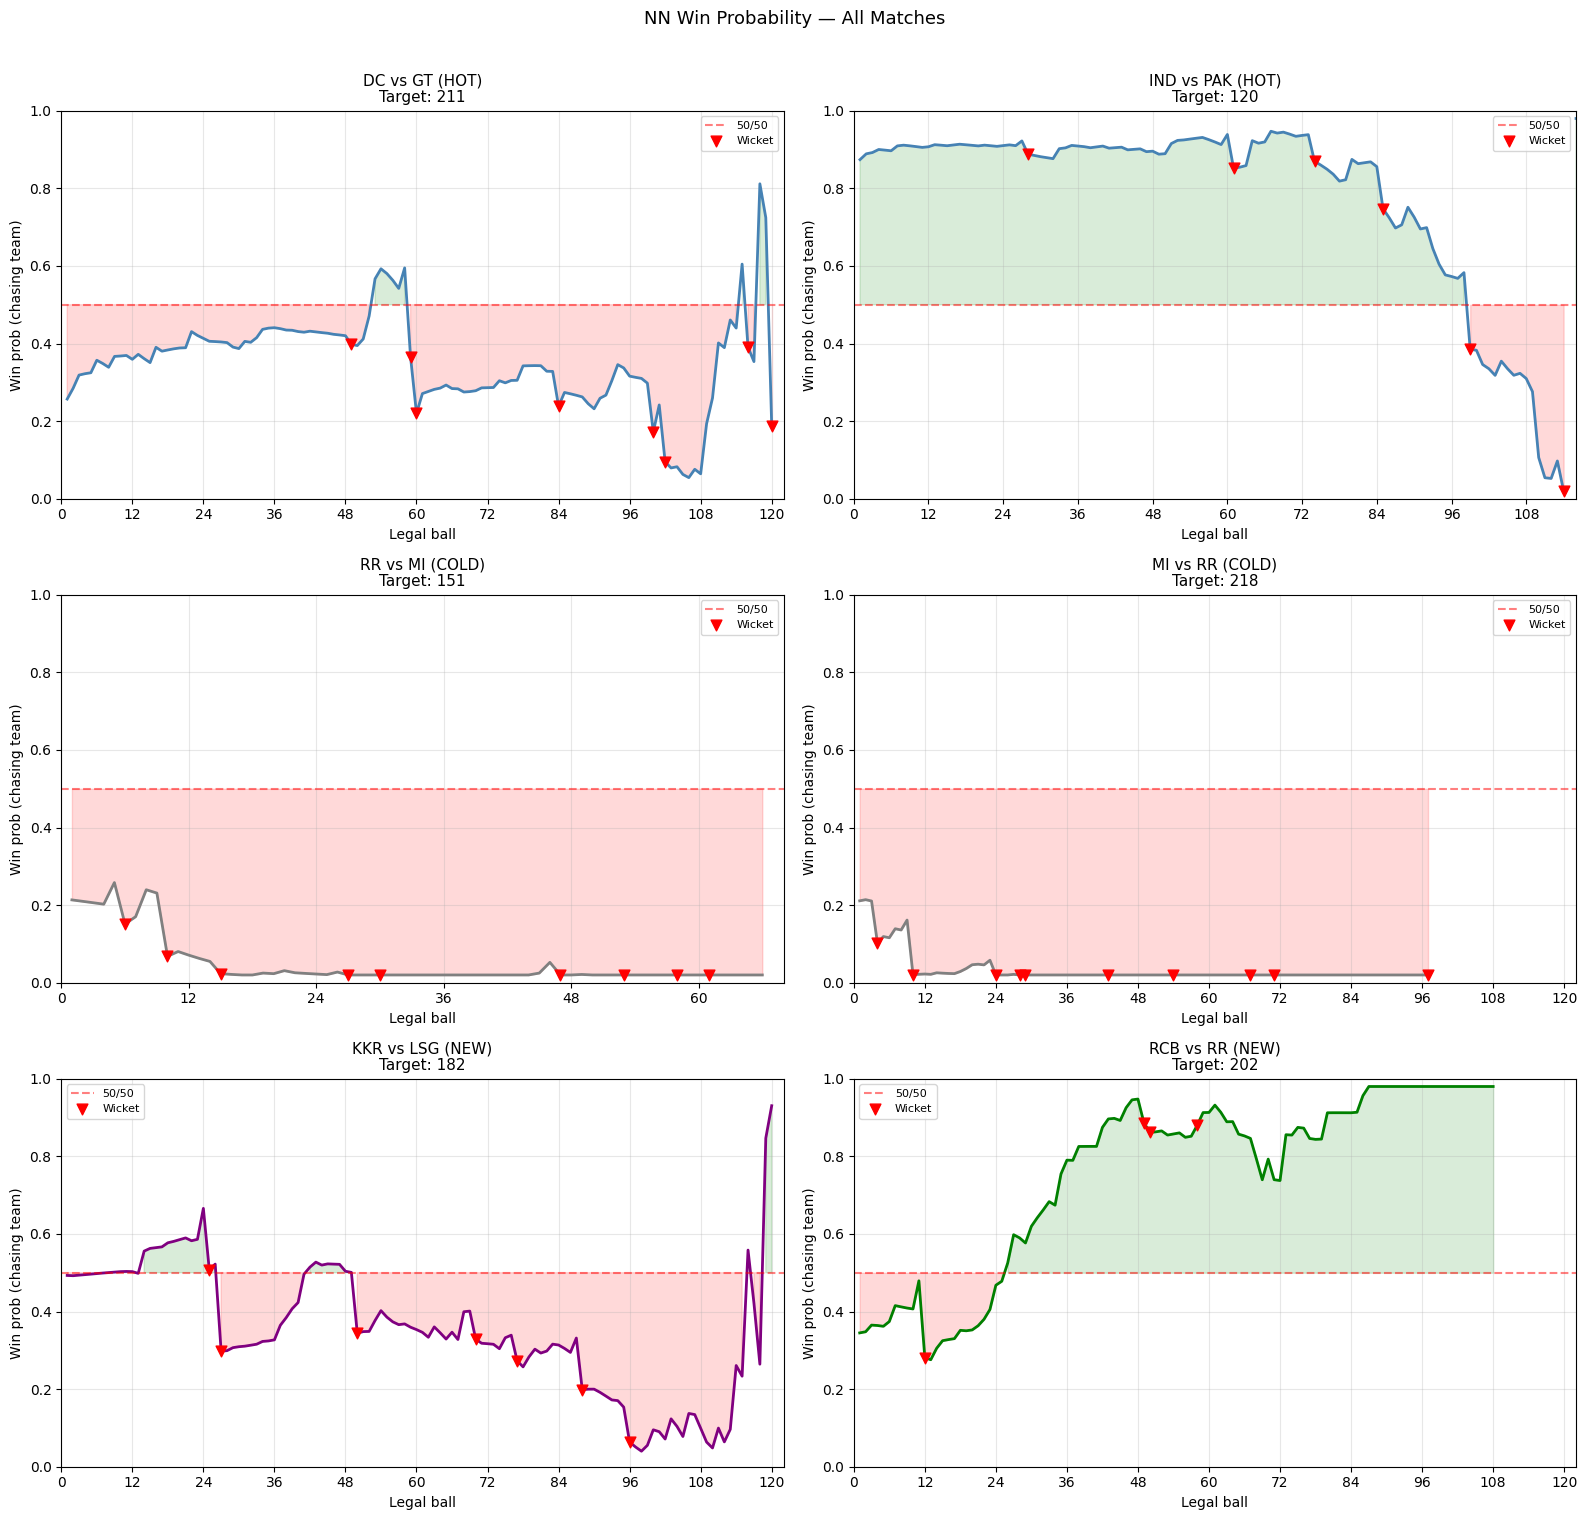

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, (label, res) in zip(axes, results.items()):
    chase, color = res['chase'], res['color']
    ax.plot(chase['legal_ball'], chase['win_prob'], color=color, linewidth=2)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50/50')
    ax.fill_between(chase['legal_ball'], chase['win_prob'], 0.5,
                    where=chase['win_prob'] >= 0.5, alpha=0.15, color='green')
    ax.fill_between(chase['legal_ball'], chase['win_prob'], 0.5,
                    where=chase['win_prob'] < 0.5, alpha=0.15, color='red')
    wk = chase[chase['is_wicket']]
    ax.scatter(wk['legal_ball'], wk['win_prob'], color='red', zorder=5, s=60, marker='v', label='Wicket')
    ax.set_title(f"{label}\nTarget: {res['target']}", fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win prob (chasing team)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, res['balls'] + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8)

plt.suptitle('NN Win Probability — All Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nn_win_prob_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: Hotness Score

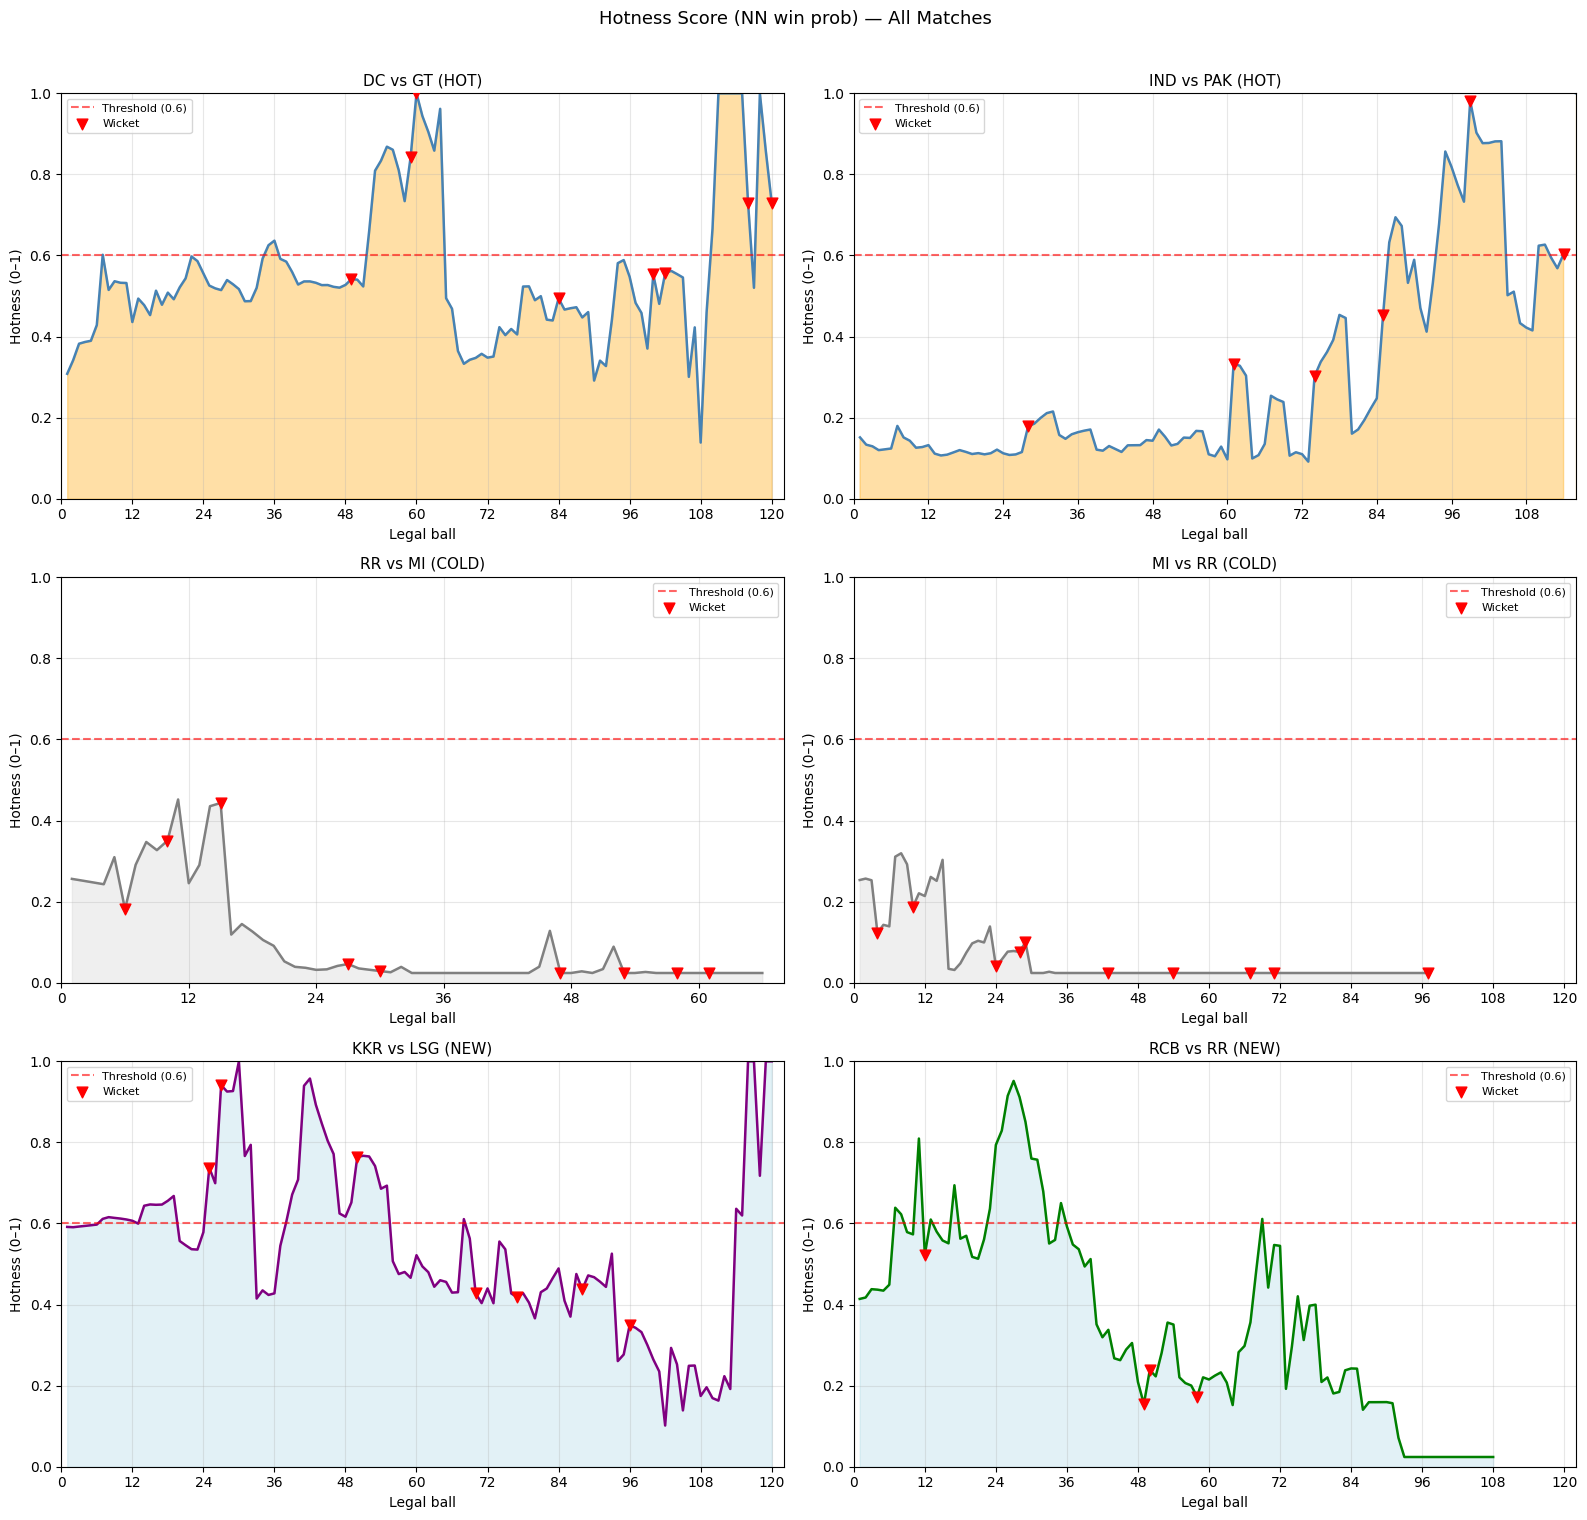

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, (label, res) in zip(axes, results.items()):
    chase  = res['chase']
    is_hot = 'HOT' in label
    is_new = 'NEW' in label
    fill_color = 'orange' if is_hot else ('lightblue' if is_new else 'lightgray')
    line_color = res['color']

    ax.fill_between(chase['legal_ball'], chase['hotness'], alpha=0.35, color=fill_color)
    ax.plot(chase['legal_ball'], chase['hotness'], color=line_color, linewidth=1.8)
    ax.axhline(0.6, color='red', linestyle='--', alpha=0.6, label='Threshold (0.6)')
    wk = chase[chase['is_wicket']]
    ax.scatter(wk['legal_ball'], wk['hotness'], color='red', zorder=5, s=60, marker='v', label='Wicket')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Hotness (0–1)')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, res['balls'] + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8)

plt.suptitle('Hotness Score (NN win prob) — All Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nn_hotness_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3: RRR vs CRR

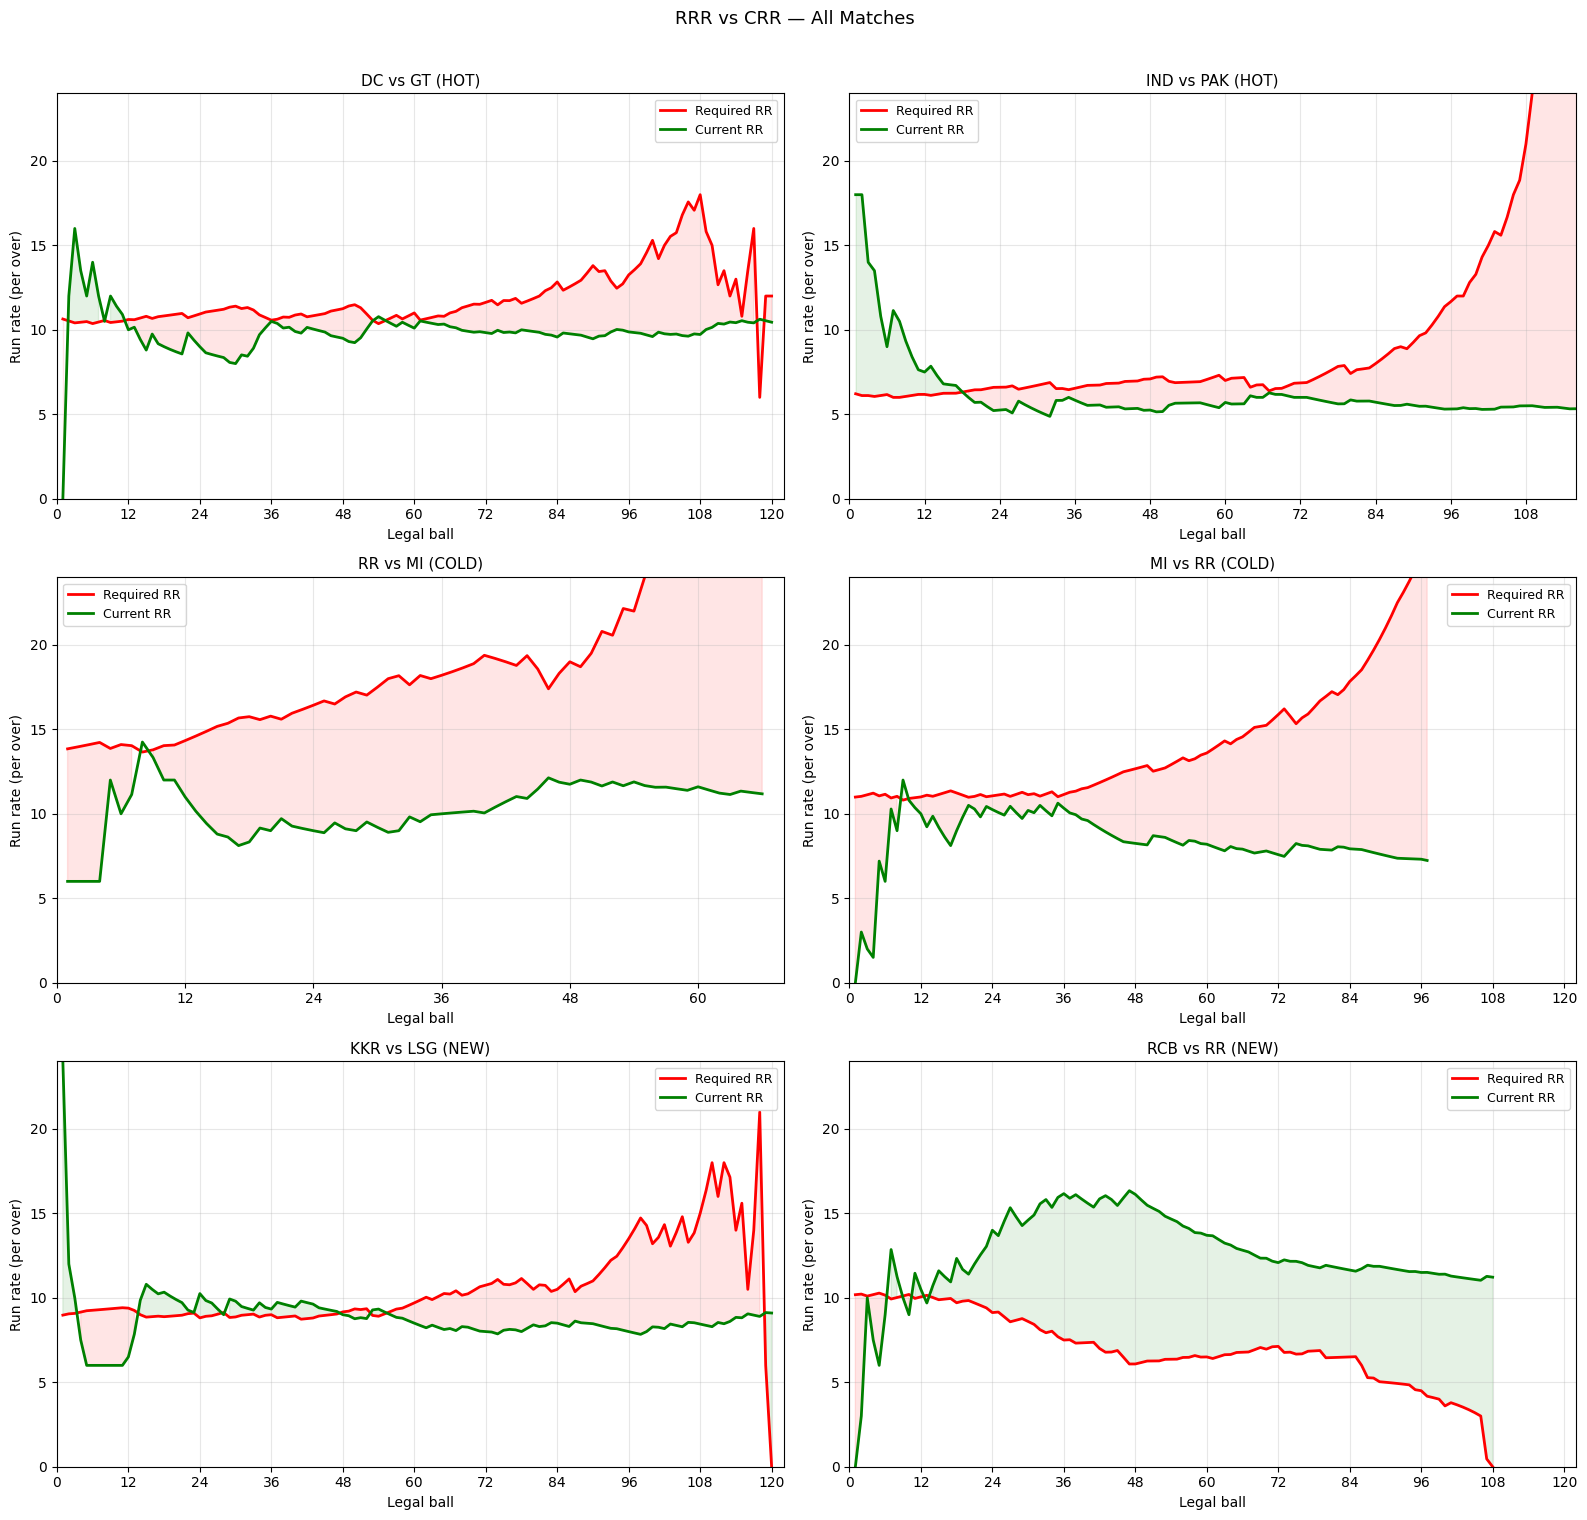

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, (label, res) in zip(axes, results.items()):
    chase = res['chase']
    ax.plot(chase['legal_ball'], chase['rrr'] * 6, label='Required RR', color='red',   linewidth=2)
    ax.plot(chase['legal_ball'], chase['crr'] * 6, label='Current RR',  color='green', linewidth=2)
    ax.fill_between(chase['legal_ball'], chase['rrr']*6, chase['crr']*6,
                    where=chase['rrr'] >= chase['crr'], alpha=0.1, color='red')
    ax.fill_between(chase['legal_ball'], chase['rrr']*6, chase['crr']*6,
                    where=chase['rrr'] < chase['crr'], alpha=0.1, color='green')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Run rate (per over)')
    ax.set_ylim(0, 24)
    ax.set_xlim(0, res['balls'] + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=9)

plt.suptitle('RRR vs CRR — All Matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## When did each match turn on?

First ball where hotness >= 0.55 sustained for 6 consecutive balls.

In [8]:
def find_heat_onset(chase, threshold=0.55, sustained=6):
    hot = chase['hotness'] >= threshold
    for i in range(len(hot) - sustained):
        if hot.iloc[i:i+sustained].all():
            row  = chase.iloc[i]
            ball = int(row['legal_ball'])
            over = (ball - 1) // 6 + 1
            return ball, over, row
    return None, None, None

def get_tag(label):
    if 'HOT'  in label: return 'HOT'
    if 'COLD' in label: return 'COLD'
    if 'NEW'  in label: return 'NEW'
    return '???'

for label, res in results.items():
    chase = res['chase']
    ball, over, row = find_heat_onset(chase)
    tag = get_tag(label)
    if ball:
        br = int(row['balls_remaining'])
        print(f"[{tag}] {label}: onset ball {ball} (over {over}), {br} balls left | "
              f"score {int(row['score'])}/{int(row['wickets_fallen'])}, "
              f"need {int(row['runs_needed'])} | "
              f"win_prob={row['win_prob']:.2f}, hotness={row['hotness']:.2f}")
    else:
        print(f"[{tag}] {label}: never sustained above threshold")
    print()

[HOT] DC vs GT (HOT): onset ball 34 (over 6), 86 balls left | score 55/0, need 156 | win_prob=0.44, hotness=0.59

[HOT] IND vs PAK (HOT): onset ball 94 (over 16), 20 balls left | score 84/4, need 36 | win_prob=0.60, hotness=0.68

[COLD] RR vs MI (COLD): never sustained above threshold

[COLD] MI vs RR (COLD): never sustained above threshold

[NEW] KKR vs LSG (NEW): onset ball 1 (over 1), 119 balls left | score 4/0, need 178 | win_prob=0.49, hotness=0.59

[NEW] RCB vs RR (NEW): onset ball 13 (over 3), 107 balls left | score 21/1, need 181 | win_prob=0.28, hotness=0.61



## Summary table

In [9]:
print(f"{'Match':<25} {'Tag':<5} {'Target':>7} {'Balls':>6} {'Final':>8} "
      f"{'MaxHot':>8} {'>0.5':>7} {'>0.7':>7} {'MaxMom':>8}")
print('-' * 85)

for label, res in results.items():
    chase = res['chase']
    tag   = 'HOT' if 'HOT' in label else 'COLD'
    final = f"{int(chase['score'].iloc[-1])}/{int(chase['wickets_fallen'].iloc[-1])}"
    print(f"{label:<25} {tag:<5} {res['target']:>7} {res['balls']:>6} {final:>8} "
          f"{chase['hotness'].max():>8.3f} "
          f"{(chase['hotness'] > 0.5).sum():>7} "
          f"{(chase['hotness'] > 0.7).sum():>7} "
          f"{chase['momentum_6'].max():>8.3f}")

Match                     Tag    Target  Balls    Final   MaxHot    >0.5    >0.7   MaxMom
-------------------------------------------------------------------------------------
DC vs GT (HOT)            HOT       211    120    209/8    1.000      71      21    0.422
IND vs PAK (HOT)          HOT       120    114    113/7    1.000      29      15    0.950
RR vs MI (COLD)           COLD      151     66    123/9    0.452       0       0    0.208
MI vs RR (COLD)           COLD      218    120   117/10    0.319       0       0    0.137
KKR vs LSG (NEW)          COLD      182    120    182/7    1.000      65      23    0.751
RCB vs RR (NEW)           COLD      202    120    202/4    0.952      36       9    0.235
